## <center> Machine Learning from Scratch at ETH Zurich
## <center> 6. Principal Component Analysis and Dimension Reduction
### <center> Zhaorui Gong &nbsp; 宫兆瑞

### 6.1 PCA Summary & Recap
#### 6.1.1 The original PCA Problem

For the centered Design Matrix $X \in \mathbb{R}^{n*d}$ s.t. $\,\mathbf E(X) = 0 \in \mathbb{R}^d$, we want to find an orthonormal matrix $W \in \mathbb{R}^{d*k}$ s.t. $\, W^T W = I_k$ which projects X onto a space with lower dimensions, i.e. $Z = XW \in \mathbb{R}^{n*k}, \, k < d$. 

Then, the reconstructed data back to the original space is $\hat{X} = XWW^T \in \mathbb{R}^{n*d}$, and the reconstruction error is $||\hat{X} - X||_{2}^{2} = \sum_{i=1}^{n} ||Wz_i - x_i||_{2}^2 = \sum_{i=1}^{n} ||WW^Tx_i - x_i||_{2}^2$, where $ z_i = W^Tx_{i}$. Note that $WW^T$ is a projection matrix.

Since $\bar{X} = 0$, the empirical variance $Var(X) = \mathbf E[(X - \mathbf{E}(X))(X - \mathbf{E}(X))^T] = \mathbf E(XX^T) = \frac{1}{n}\sum_{i=1}^{n}x_i x_i^T$. Then, we could show that the goal to minimize the reconstruction error is equivalent to maximize the projection variance:
$$
W^* = \operatorname*{\argmin}_{W^T W = I_k}\sum_{i=1}^{n} ||WW^Tx_i - x_i||_{2}^2 = \operatorname*{\argmax}_{W^T W = I_k}Var(XW) = \operatorname*{\argmax}_{W^T W = I_k}\sum_{i=1}^{n}W^Tx_i x_i^TW
$$
The latter could be viewed as an optimization problem solved by the Lagrange Multiplier, which transforms the question into solving the eigenvectors of the empirical variance $\Sigma$. The solutions $v_1, ..., v_d$ are called the jth principal component of $X$, $j = 1, ..., d$ and $\lambda_1 \ge , ..., \ge \lambda_d$ are the eigenvalues of  $\Sigma$. We could pick any k <= d to reduce the dimensions of the data, depending on the information of reconstructed data contain. 

Thus, we have solutions for $j = 1, ..., k \le d$ and $i = 1, ..., n$:
$$
W^* = [v_1, ..., v_k], \;\;\;z_i = W^Tx_i, \;\;\; Z = XW
$$ 
and Corollary:
$$
Var(Z) = diag(\lambda_1, ..., \lambda_k), \;\;\;\Sigma = \sum_{j=1}^{d}\lambda_j v_j v_j^T, \;\;\; v_j^T \Sigma v_j = \lambda_j
$$
#### 6.1.2 PCA vs. K-Means
PCA and K-Means solve a similar unsupervised learning problem, both aiming to compress the data but with different constraints.

PCA: For $W \in \mathbb{R}^{d*k}$ orthonormal and arbitrary $z_1, ..., z_n \in \mathbb{R}^k$,
$$
(W, z_1, ..., z_n) = \operatorname*{\argmin}_{W^T W = I_k; z}\sum_{i=1}^{n} ||Wz_i - x_i||_{2}^2
$$
K-Means (equivalent formulation): For arbitrary $W \in \mathbb{R}^{d*k}$ and $z_1, ..., z_n \in {e_1, ..., e_k}$, the set of unit vectors, and k is the number of clusters,
$$
(W, z_1, ..., z_n) = \operatorname*{\argmin}_{W; z}\sum_{i=1}^{n} ||Wz_i - x_i||_{2}^2
$$


#### 6.1.3 PCA via SVD
$$
\Sigma = \frac{1}{n}X^TX = \frac{1}{n}VS^TU^TUSV^T = \frac{1}{n}VS^TSV^T = V\frac{S^2}{n}V^T
$$
Note that the singular value decomposition of $X$ is in fact the spectral decomposition of $\Sigma$. Therefore, the singular vectors of $X$ in $V$ are the eigenvectors of $\Sigma$. 

It is clearer if we denote this as the original form of SVD: $Z := XV = US$, where $V^T = V^{-1}$. We also have $\lambda_i = \frac{\sigma_i^2}{n}, \,i = 1,..., d $.

| 维度           | SVD                                  | 特征分解                     |
|----------------|--------------------------------------|------------------------------|
| 数值稳定性     | 更稳定（conditioning数低）             | 不稳定（条件数平方）         |
| 计算效率       | 适合高维数据$~O(\min(n^2d, nd^2))$   | 仅限低维场景 $O(d^3)$          |
| 内存占用       | 无需存储协方差矩阵                   | 需存储 $d \times d$ 矩阵     |
| 实现复杂度     | 直接调用LAPACK的`gesdd`              | 需手动中心化+协方差计算      |
| 实际应用       | sklearn/scikit-learn的默认选择       | 教学演示                     |

### 6.2 PCA的代码实现

In [48]:
import numpy as np
import matplotlib.pyplot as plt

(2,)


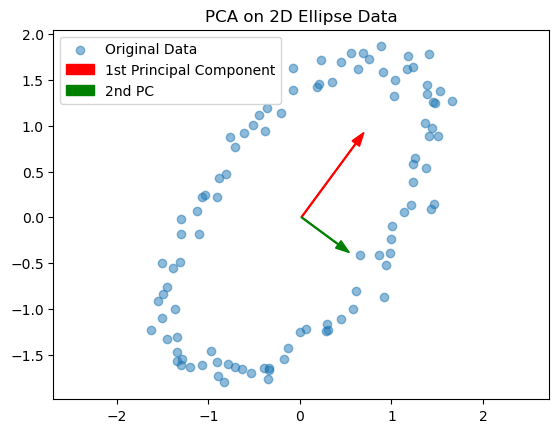

In [81]:
class PCA_basic:
    def __init__(self, n_components):
        self.K = n_components
        self.components_ = None  # 主成分方向（行向量）
        self.mean_ = None        # 数据的均值
    
    def fit_PC(self, X):
        """训练PCA模型"""
        self.mean_ = np.mean(X, axis = 0)  # 对n行取平均，得到行向量
        X_centered = X - self.mean_  # centralized data
        
        U, S, Vt = np.linalg.svd(X_centered, full_matrices=False)  # Reduced SVD
        self.components_ = Vt[:self.K]
        return self
    
    def transform(self, X):
        """将数据投影到主成分空间"""
        assert self.mean_ is not None, "必须先调用fit方法！"
        X_centered = X - self.mean_
        return np.dot(X_centered, self.components_.T)
    
    def fit_transform(self, X):
        self.fit_PC(X)
        return self.transform(X)
    

def generate_ellipse_data(n_samples=100, noise=0.1):
    """生成倾斜的椭圆数据集"""
    np.random.seed(200)
    # 生成圆形数据
    theta = np.linspace(0, 2*np.pi, n_samples)   # 在[0， 2pi]上取点
    x = np.cos(theta)
    y = 2*np.sin(theta)
    data = np.vstack([x, y]).T
    
    # 添加旋转和噪声
    rotation_matrix = np.array([[0.8, -0.6], [0.6, 0.8]])
    data_rotated = np.dot(data, rotation_matrix)
    data_rotated += noise * np.random.randn(n_samples, 2)
    
    return data_rotated

X = generate_ellipse_data()
# 初始化PCA（降维到2维）
pca = PCA_basic(n_components=2)
X_pca = pca.fit_transform(X)
print(np.shape(pca.mean_))

# 绘制原始数据
plt.scatter(X[:, 0], X[:, 1], alpha=0.5, label='Original Data')

# 绘制主成分方向（红色箭头）
origin = pca.mean_  # 形状 (2,)
component_1 = pca.components_[0]  # 取第一主成分，形状 (2,)

# 使用plt.arrow绘制箭头，标注两个主成分
plt.arrow(
    x=origin[0], y=origin[1],          # 起点坐标
    dx=-component_1[0], dy=-component_1[1],   # 方向向量
    color='r', width=0.01, head_width=0.1, 
    label='1st Principal Component'
)
component_2 = pca.components_[1]  # 取第二主成分，形状 (2,)
plt.arrow(
    x=origin[0], y=origin[1],          # 起点坐标
    dx=-component_2[0]/2, dy=-component_2[1]/2,   # 方向向量，兼有长度，可以手动改
    color='g', width=0.01, head_width=0.1, 
    label='2nd PC'
)

plt.title("PCA on 2D Ellipse Data")
plt.axis('equal')
plt.legend()
plt.show()


### 6.3 Kernel PCA

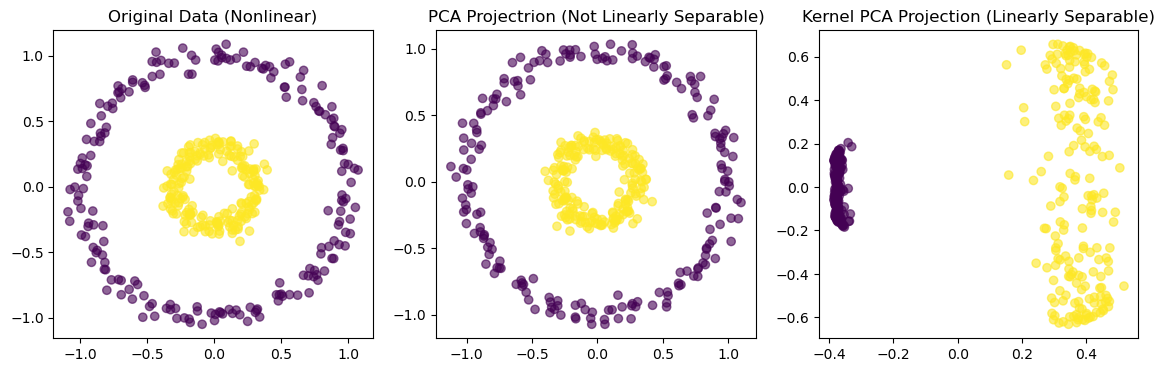

In [82]:
from sklearn.datasets import make_circles
from sklearn.decomposition import KernelPCA

# 生成同心圆数据
X, y = make_circles(n_samples=400, factor=0.3, noise=0.05, random_state=200)

# 普通PCA
pca = PCA_basic(n_components = 2)
X_pca = pca.fit_transform(X)

# 核PCA（RBF核）
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=5)
X_kpca = kpca.fit_transform(X)

# 可视化
plt.figure(figsize=(14, 4))
plt.subplot(1,3,1)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.title("Original Data (Nonlinear)")

plt.subplot(1,3,2)
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.title("PCA Projectrion (Not Linearly Separable)")

plt.subplot(133)
plt.scatter(X_kpca[:, 0], X_kpca[:, 1], c=y, cmap='viridis', alpha=0.6)
plt.title("Kernel PCA Projection (Linearly Separable)")
plt.show()

We recall that PCA transforms the data linearly. Intuitively, it means that the coordinate system will be centered, rescaled on each component with respected to its variance and finally be rotated. The obtained data from this transformation is isotropic and can now be projected on its principal components.

Thus, looking at the projection made using PCA (i.e. the middle figure), we see that there is no change regarding the scaling; indeed the data being two concentric circles centered in zero, the original data is already isotropic. However, we can see that the data have been rotated. As a conclusion, we see that such a projection would not help if define a linear classifier to distinguish samples from both classes.

Using a kernel allows to make a non-linear projection. Here, by using an RBF kernel, we expect that the projection will unfold the dataset while keeping approximately preserving the relative distances of pairs of data points that are close to one another in the original space.

We observe such behaviour in the figure on the right: the samples of a given class are closer to each other than the samples from the opposite class, untangling both sample sets. Now, we can use a linear classifier to separate the samples from the two classes.